## SubGraphs With LLM 

**Subgraph:** We'll have a subgraph that calculates the discount for a customer based on their purchase amount.

**Parent Graph:** We'll generate a personalized discount report using the result from the subgraph, which is then enhanced by invoking an LLM to provide a personalized message.

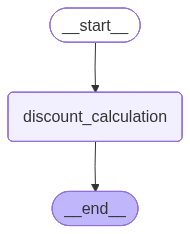

In [2]:
from typing_extensions import TypedDict
from langgraph.graph.state import StateGraph, START
from langchain_aws import ChatBedrockConverse
from langchain.schema import HumanMessage

# LLM setup for personalized report generation
llm = ChatBedrockConverse(
    model_id="amazon.nova-lite-v1:0",  # AWS Bedrock model ID
    region_name="us-east-1",           # AWS region
    temperature=0.7,                   # More creative output
    max_tokens=100                     # Generate a message with sufficient detail
)

# --- Subgraph definition ---

class PurchaseState(TypedDict):
    purchase_amount: float
    discount: float

# Discount calculation logic (subgraph)
def discount_calculation(state: PurchaseState):
    purchase_amount = state["purchase_amount"]
    
    if purchase_amount >= 1000:
        discount = 20  # 20% discount
    elif purchase_amount >= 500:
        discount = 10  # 10% discount
    elif purchase_amount >= 200:
        discount = 5  # 5% discount
    else:
        discount = 0  # No discount
    
    return {"discount": discount}

# Build the subgraph to calculate discount
subgraph_builder = StateGraph(PurchaseState)
subgraph_builder.add_node("discount_calculation", discount_calculation)
subgraph_builder.add_edge(START, "discount_calculation")
discount_subgraph = subgraph_builder.compile()
discount_subgraph

In [ ]:
# -----------------------------
# Parent State (includes shared keys)
# -----------------------------
class CustomerState(TypedDict):
    name: str
    purchase_amount: float
    discount: float
    discount_report: str


def generate_discount_report(state: CustomerState):
    #  No subgraph.invoke() here
    # The subgraph already computed "discount" and wrote it into shared state.
    discount = state["discount"]

    # Basic report
    report = f"{state['name']} is eligible for a {discount}% discount on their purchase."

    # Personalized message via LLM
    prompt = (
       f"Generate a short, friendly personalized message for {state['name']} "
        f"who received a {discount}% discount."
    )
    response = llm.invoke([HumanMessage(content=prompt)])

    report += " " + response.content
    return {"discount_report": report}


# Build the parent graph
parent_builder = StateGraph(CustomerState)

#  Add the compiled subgraph directly as a node (no wrapper needed)
parent_builder.add_node("apply_discount", discount_subgraph)

# Normal node (uses discount written by subgraph)
parent_builder.add_node("generate_discount_report", generate_discount_report)

# Flow: START -> subgraph(node) -> report node -> END
parent_builder.add_edge(START, "apply_discount")
parent_builder.add_edge("apply_discount", "generate_discount_report")
parent_builder.add_edge("generate_discount_report", END)

discount_report_graph = parent_builder.compile()
discount_report_graph

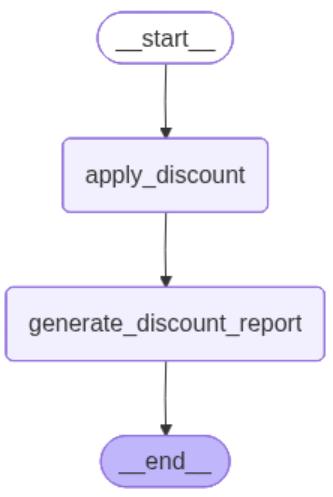

In [6]:
from rich import print

In [7]:
# --- Sample invocation ---
customer_state = {"name": "Raj", "purchase_amount": 750}  # Customer with $750 purchase
report = discount_report_graph.invoke(customer_state)

# Print the generated report
print(report)

{
    'name': 'Raj',
    'purchase_amount': 750,
    'discount': 10,
    'discount_report': "Raj is eligible for a 10% discount on their purchase. Subject: Special Offer Just for You, 
Raj – Enjoy 10% Off Your Next Purchase!\n\nDear Raj,\n\nWe hope this message finds you well! We wanted to 
personally thank you for being a valued customer and to share some exciting news with you.\n\nAs a token of our 
appreciation, we're pleased to offer you an exclusive 10% discount on your next purchase. Whether you're looking to
refresh your wardrobe, upgrade your tech, or explore something new, we have a wide"
}

In [8]:
for chunk in discount_report_graph.stream(customer_state,subgraphs=True):
    print(chunk)

(('generate_discount_report:fe3cebdc-016b-b978-fecc-22ae652026c2',), {'discount_calculation': {'discount': 10}})

(
    (),
    {
        'generate_discount_report': {
            'discount': 10,
            'discount_report': "Raj is eligible for a 10% discount on their purchase. Subject: Special Offer Just 
for You, Raj!\n\nDear Raj,\n\nWe hope this message finds you well! We wanted to personally thank you for choosing 
us and to share some exciting news. As a valued customer, we're pleased to offer you an exclusive 10% discount on 
your next purchase.\n\nWhether you're looking for the latest trends, top-quality products, or simply the best 
value, we're here to make sure you get it all at a price you'll love"
        }
    }
)